In [ ]:
!pip install ultralytics

In [ ]:
# Cell 1: Setup
from google.colab import drive
import os

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Install YOLO
!pip install ultralytics -q

# 3. Define Base Path (Matches your screenshot)
base_path = '/content/drive/MyDrive/data/dal-shemagh-detection-challenge'
labels_dir = os.path.join(base_path, 'labels/train')
images_dir = os.path.join(base_path, 'images/train')

print(f"✅ Base path set to: {base_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Base path set to: /content/drive/MyDrive/data/dal-shemagh-detection-challenge


Inspecting: 364.jpg
--- Classes Found in this Image ---
Class ID: 1


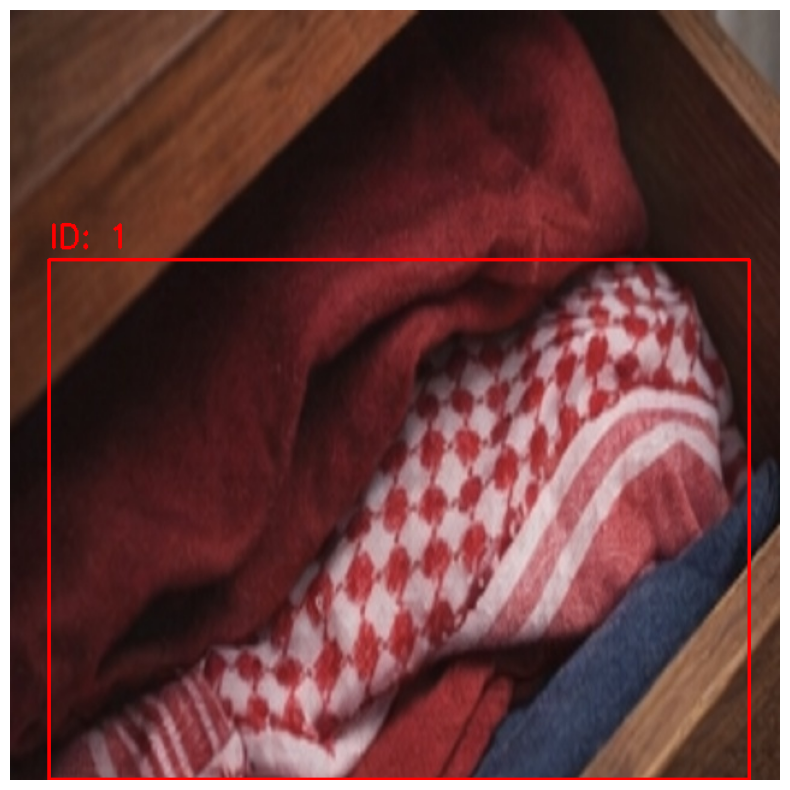

In [ ]:
# Cell 2: Visualize to find Class IDs
import cv2
import matplotlib.pyplot as plt
import glob
import random

# Get random text file
txt_files = glob.glob(os.path.join(labels_dir, '*.txt'))
random_txt = random.choice(txt_files)
image_file = os.path.join(images_dir, os.path.basename(random_txt).replace('.txt', '.jpg'))

print(f"Inspecting: {os.path.basename(image_file)}")

# Read Image
img = cv2.imread(image_file)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Read Labels
with open(random_txt, 'r') as f:
    lines = f.readlines()

print("--- Classes Found in this Image ---")
for line in lines:
    parts = line.strip().split()
    cls_id = int(parts[0])
    x, y, bw, bh = map(float, parts[1:])

    # Draw box
    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img, f"ID: {cls_id}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
    print(f"Class ID: {cls_id}")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
import pandas as pd
import shutil
import os
from tqdm import tqdm

# --- CONFIGURATION ---
BASE_PATH = '/content/drive/MyDrive/data/dal-shemagh-detection-challenge'
ORIGINAL_LABELS_DIR = os.path.join(BASE_PATH, 'labels/train')
NEW_LABELS_DIR = os.path.join(BASE_PATH, 'labels_custom/train')
CSV_PATH = os.path.join(BASE_PATH, 'train_labels.csv')

# The ID for Shemagh in your ORIGINAL data
SHEMAGH_ID = 1

# 1. Setup New Directory
if os.path.exists(NEW_LABELS_DIR):
    shutil.rmtree(NEW_LABELS_DIR)
os.makedirs(NEW_LABELS_DIR)

# 2. Load CSV
df = pd.read_csv(CSV_PATH)
# Handle boolean (some CSVs use "True"/"False" strings, others use actual booleans)
# This trick handles both:
df['right_place'] = df['right_place'].astype(str).map({'True': True, 'False': False, '1': True, '0': False})

print(f"Processing {len(df)} files...")

count_correct = 0
count_incorrect = 0

for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    filename = row['filename']
    is_correct = row['right_place']

    # Construct paths
    txt_name = filename.replace('.jpg', '.txt') # Ensure extension matches
    src_txt = os.path.join(ORIGINAL_LABELS_DIR, txt_name)
    dst_txt = os.path.join(NEW_LABELS_DIR, txt_name)

    if not os.path.exists(src_txt):
        continue

    with open(src_txt, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        cls_id = int(parts[0])

        # LOGIC:
        if cls_id == SHEMAGH_ID: # If it's a Shemagh (1)
            if is_correct:
                # Keep as 1 (Correct)
                parts[0] = '1'
                count_correct += 1
            else:
                # Change to 2 (Incorrect)
                parts[0] = '2'
                count_incorrect += 1
        else:
            # It's a Head (0), keep it as 0
            pass

        new_lines.append(" ".join(parts))

    with open(dst_txt, 'w') as f:
        f.write('\n'.join(new_lines))

print(f"\nDone! Created custom labels.")
print(f"Shemagh Correct (Class 1): {count_correct}")
print(f"Shemagh Incorrect (Class 2): {count_incorrect}")

Processing 651 files...


100%|██████████| 651/651 [00:07<00:00, 84.41it/s]


Done! Created custom labels.
Shemagh Correct (Class 1): 7
Shemagh Incorrect (Class 2): 158


In [ ]:
yaml_content = f"""
path: {BASE_PATH}
train: images/train
val: images/train

# Classes
nc: 3
names:
  0: Head
  1: Shemagh_Correct
  2: Shemagh_Incorrect
"""

with open(os.path.join(BASE_PATH, 'dal_shemagh.yaml'), 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml updated for 3 classes!")

✅ data.yaml updated for 3 classes!


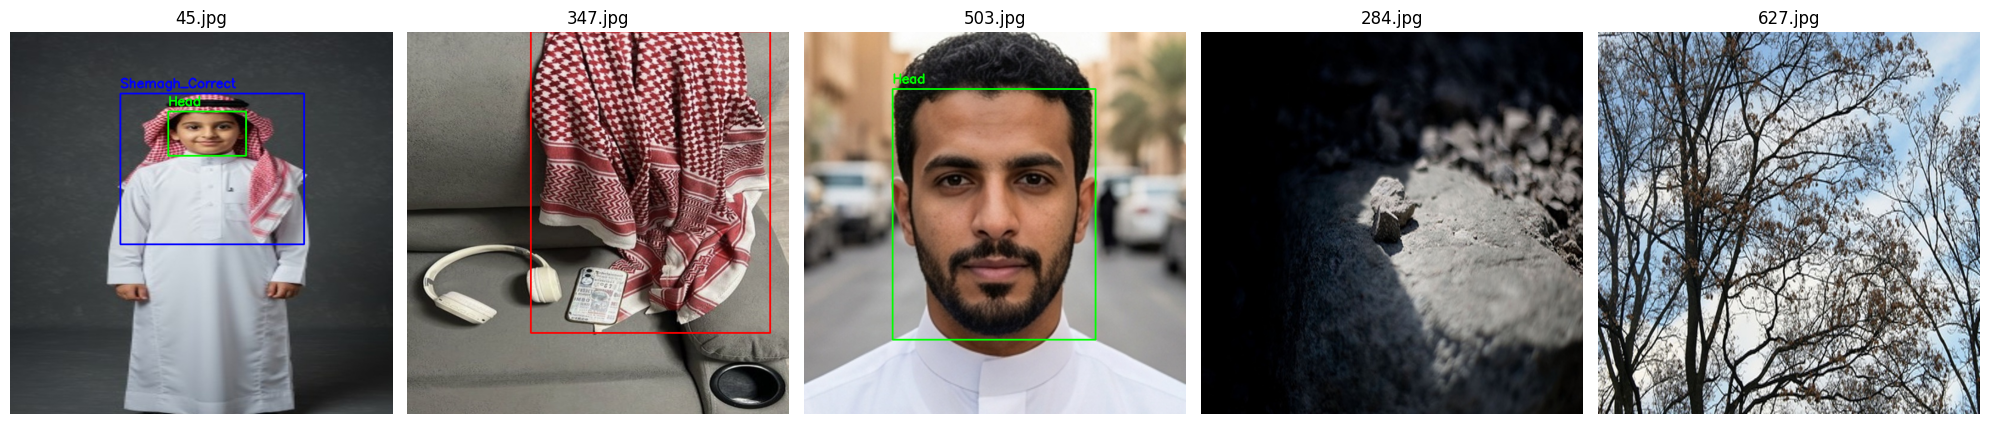

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random

# Class mapping
class_map = {0: 'Head', 1: 'Shemagh_Correct', 2: 'Shemagh_Incorrect'}
colors = {0: (0, 255, 0), 1: (0, 0, 255), 2: (255, 0, 0)}

# Target files
sample_images = ['45.jpg']
all_images = [f for f in os.listdir(images_dir) if f.endswith('.jpg') and f != '45.jpg']
sample_images.extend(random.sample(all_images, 4))

plt.figure(figsize=(20, 10))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(images_dir, img_name)
    label_path = os.path.join(NEW_LABELS_DIR, img_name.replace('.jpg', '.txt'))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            cls_id, x, y, bw, bh = map(float, line.strip().split())
            cls_id = int(cls_id)

            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            color = colors.get(cls_id, (255, 255, 255))
            label_text = class_map.get(cls_id, f'ID:{cls_id}')

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, label_text, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Training
import os
from ultralytics import YOLO

# --- 1. FOLDER FIX (Crucial for YOLO to find labels) ---
# YOLO expects the folder to be named exactly 'labels'.
# We will swap your 'labels_custom' to be the main 'labels' folder.

labels_current = os.path.join(base_path, 'labels')
labels_custom = os.path.join(base_path, 'labels_custom')
labels_original_backup = os.path.join(base_path, 'labels_original')

# Only run if we haven't already swapped them
if os.path.exists(labels_custom):
    print("🔄 Swapping folder names so YOLO finds the new data...")

    # 1. Rename existing 'labels' to 'labels_original' (Backup)
    if os.path.exists(labels_current):
        os.rename(labels_current, labels_original_backup)

    # 2. Rename 'labels_custom' to 'labels' (Active)
    os.rename(labels_custom, labels_current)
    print("✅ Folder swapped! 'labels' now contains your custom classes.")
else:
    print("ℹ️ Folders appear to be already set up correctly.")


# --- 2. START TRAINING ---
print("\n🚀 Starting Training...")

# Load the model (Medium version is good for this competition)
# You can try 'yolov8l.pt' if you have Colab Pro for better accuracy
model = YOLO('yolov8m.pt')

# Train
results = model.train(
    data=os.path.join(base_path, 'dal_shemagh.yaml'),
    epochs=50,           # 50 is a good start. Increase to 100 if needed.
    imgsz=640,           # Standard size
    batch=16,            # Lower to 8 if you run out of GPU memory
    patience=10,         # Stop early if no improvement for 10 epochs
    project=os.path.join(base_path, 'runs'),
    name='shemagh_model_v1',
    exist_ok=True        # Overwrite if name exists
)

print("✅ Training Complete!")

🔄 Swapping folder names so YOLO finds the new data...
✅ Folder swapped! 'labels' now contains your custom classes.

🚀 Starting Training...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/dal-shemagh-detection-challenge/dal_shemagh.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train

# End of Training

## generalization test begins here !!!

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.9 MB/s eta 0:00:00


In [38]:
import cv2
import numpy as np
from ultralytics import YOLO
import torch
import os

# Define the model path
model_path = '/content/drive/MyDrive/data/dal-shemagh-detection-challenge/final_model_export/shemagh_detector_best.pt'

# Load the model
if os.path.exists(model_path):
    model = YOLO(model_path)
    print(f"✅ Model loaded successfully from: {model_path}")
else:
    print(f"❌ Model file not found at: {model_path}")

def detect_smart_shemagh(image_path, model, conf=0.3, iou=0.10, coverage_threshold=0.2):
    # 1. Run Prediction
    results = model.predict(image_path, conf=conf, iou=iou, agnostic_nms=False, verbose=False)[0]

    # 2. Extract Data
    boxes = results.boxes.xyxy.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy().copy()
    confs = results.boxes.conf.cpu().numpy()

    def get_coverage(box_large, box_small):
        xA = max(box_large[0], box_small[0])
        yA = max(box_large[1], box_small[1])
        xB = min(box_large[2], box_small[2])
        yB = min(box_large[3], box_small[3])
        interArea = max(0, xB - xA) * max(0, yB - yA)
        smallArea = (box_small[2] - box_small[0]) * (box_small[3] - box_small[1])
        return interArea / smallArea if smallArea > 0 else 0

    head_indices = [i for i, c in enumerate(classes) if c == 0]
    shemagh_indices = [i for i, c in enumerate(classes) if c in [1, 2]]

    # Step 2: NMS for Shemaghs
    kept_shemaghs = []
    shemagh_indices.sort(key=lambda i: confs[i], reverse=True)
    while len(shemagh_indices) > 0:
        current = shemagh_indices.pop(0)
        keep_current = True
        for kept in kept_shemaghs:
            xA, yA = max(boxes[current][0], boxes[kept][0]), max(boxes[current][1], boxes[kept][1])
            xB, yB = min(boxes[current][2], boxes[kept][2]), min(boxes[current][3], boxes[kept][3])
            inter = max(0, xB - xA) * max(0, yB - yA)
            area_curr = (boxes[current][2]-boxes[current][0]) * (boxes[current][3]-boxes[current][1])
            area_kept = (boxes[kept][2]-boxes[kept][0]) * (boxes[kept][3]-boxes[kept][1])
            iou_val = inter / (area_curr + area_kept - inter)
            if iou_val > 0.5:
                keep_current = False
                break
        if keep_current:
            kept_shemaghs.append(current)

    # Step 3: "Smart" Reclassification Logic
    for idx in kept_shemaghs:
        if classes[idx] == 2.0:
            for h_idx in head_indices:
                if get_coverage(boxes[idx], boxes[h_idx]) > coverage_threshold:
                    classes[idx] = 1.0
                    break

    final_draw_list = []
    heads_covered = set()

    for s_idx in kept_shemaghs:
        final_draw_list.append((s_idx, classes[s_idx]))
        for h_idx in head_indices:
            if get_coverage(boxes[s_idx], boxes[h_idx]) > coverage_threshold:
                heads_covered.add(h_idx)
                final_draw_list.append((h_idx, 0))

    for h_idx in head_indices:
        if h_idx not in heads_covered:
            final_draw_list.append((h_idx, 2.0))

    # --- CUSTOM PLOTTING ---
    img = results.orig_img.copy()

    # 🎨 Color and Label Updates
    color_map = {0: (220, 220, 220), 1: (0, 255, 0), 2: (0, 0, 255)}
    label_map = {0: "Head", 1: "Wearing Shemagh", 2: "Not Wearing"}

    for idx, cls_id in final_draw_list:
        box = boxes[idx].astype(int)
        color = color_map.get(cls_id, (255, 255, 255))
        label_text = label_map.get(cls_id, "Unknown")

        # Draw Bounding Box
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, 2)

        # 🔽 Smaller Font
        font_scale = 0.35
        font_thickness = 1

        label_str = f"{label_text} {confs[idx]:.2f}"
        (w, h), baseline = cv2.getTextSize(label_str, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)

        # Draw label background
        cv2.rectangle(img, (box[0], box[1] - h - 6), (box[0] + w, box[1]), color, -1)

        # Draw Text
        text_color = (0, 0, 0) if cls_id == 1 else (255, 255, 255)
        cv2.putText(img, label_str, (box[0], box[1] - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, font_thickness)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

✅ Model loaded successfully from: /content/drive/MyDrive/data/dal-shemagh-detection-challenge/final_model_export/shemagh_detector_best.pt


Running predictions on 5 random images...



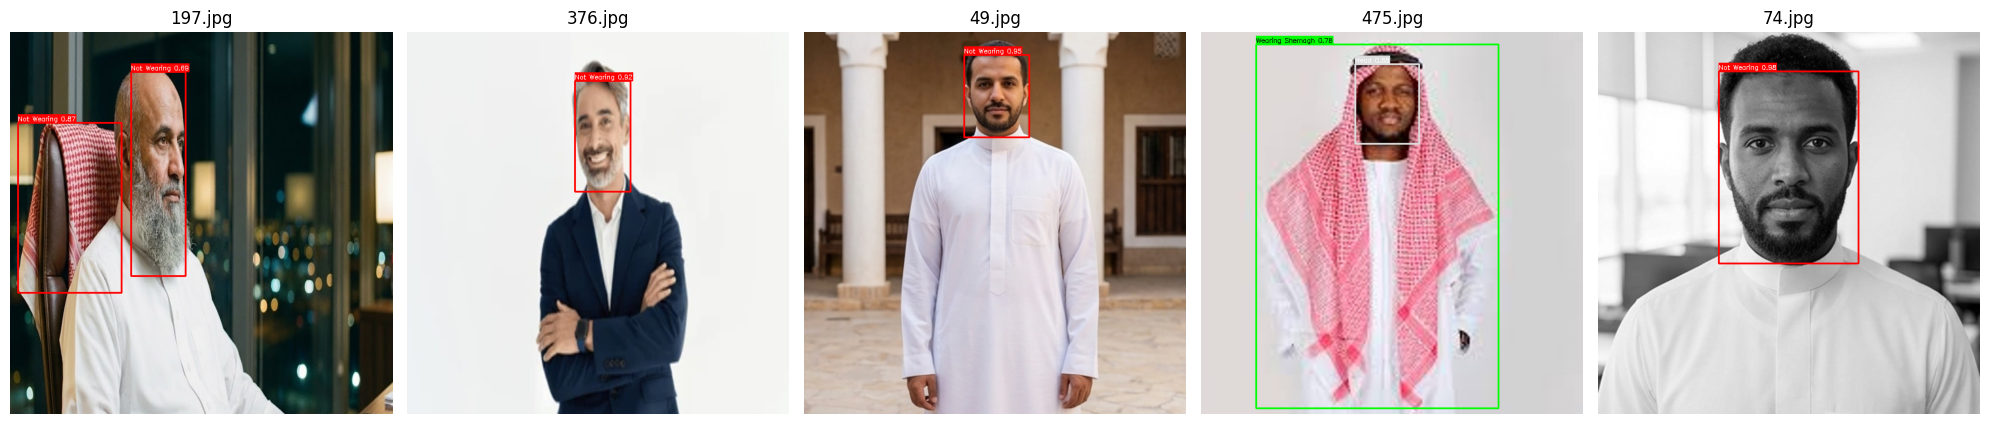

In [53]:
import os
import random
import glob
import matplotlib.pyplot as plt

# 1. Setup Paths
test_dir = '/content/drive/MyDrive/data/dal-shemagh-detection-challenge/images/test'

# 2. Get all images and select 5 randomly
all_images = glob.glob(os.path.join(test_dir, '*.jpg')) + glob.glob(os.path.join(test_dir, '*.png'))

if len(all_images) >= 5:
    selected_paths = random.sample(all_images, 5)
else:
    selected_paths = all_images
    print(f"Note: Only {len(all_images)} images found in directory.")

# 3. Run Loop and Display Results
print(f"Running predictions on {len(selected_paths)} random images...\n")

plt.figure(figsize=(20, 10))

for i, img_path in enumerate(selected_paths):
    # Call your smart detection function
    res_rgb = detect_smart_shemagh(
        img_path,
        model,
    )

    # Display in a 1x5 grid
    plt.subplot(1, 5, i + 1)
    plt.imshow(res_rgb)
    plt.title(os.path.basename(img_path))
    plt.axis('off')

plt.tight_layout()
plt.show()

Running predictions on 7 images...



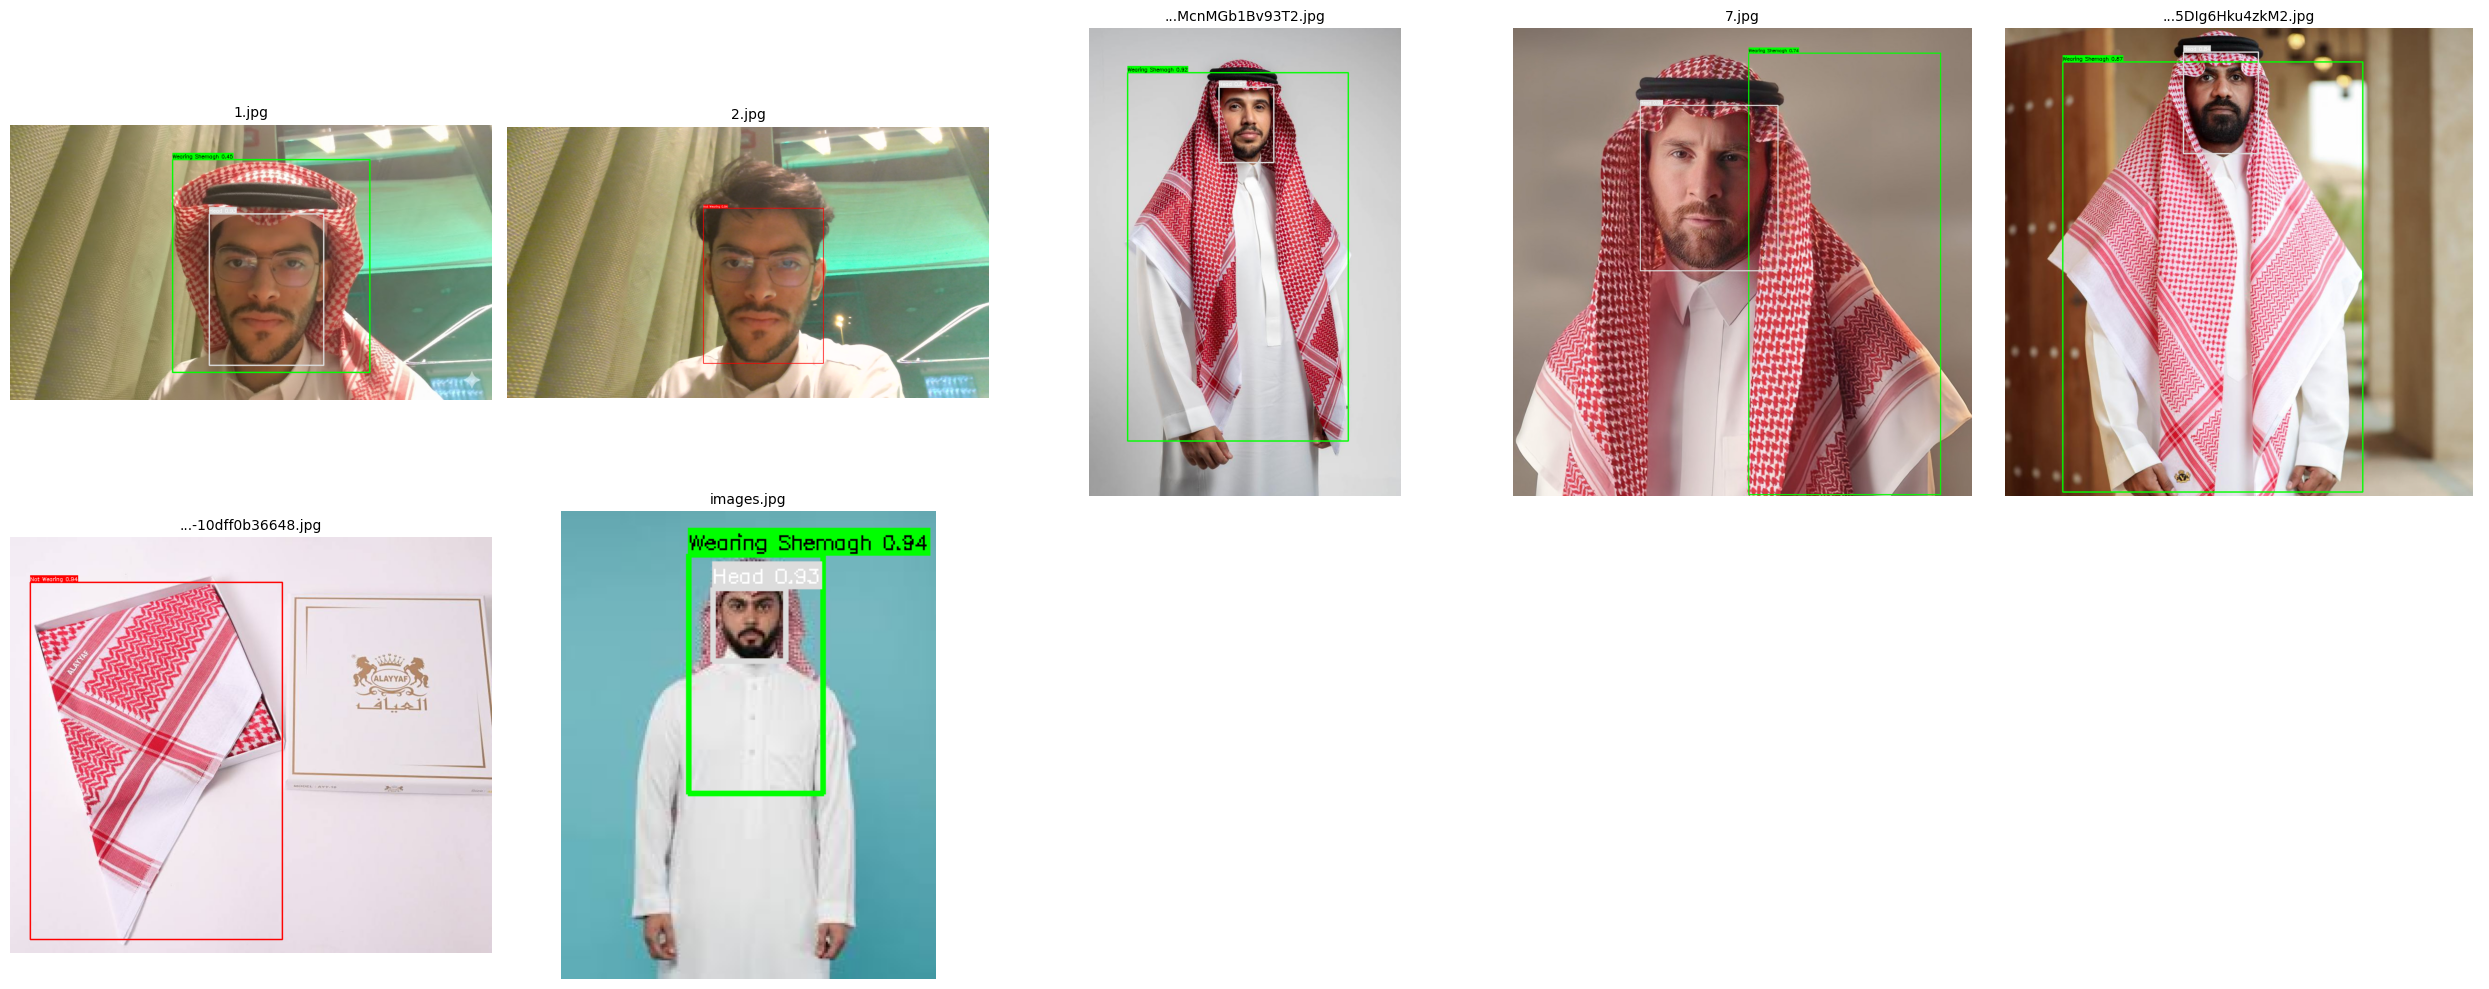

In [51]:
import os
import glob
import matplotlib.pyplot as plt
import math

# 1. Setup Path
test_dir = '/content/drive/MyDrive/data/separate_test'

# 2. Get ALL images in folder
selected_paths = sorted(glob.glob(os.path.join(test_dir, '*.jpg')) + \
                 glob.glob(os.path.join(test_dir, '*.png')))

num_images = len(selected_paths)
if num_images == 0:
    print("No images found in the specified directory.")
else:
    print(f"Running predictions on {num_images} images...\n")

    # 3. Setup Dynamic Grid
    cols = 5
    rows = math.ceil(num_images / cols) # Automatically calculates rows based on image count

    # Scale the figure height based on the number of rows (5 inches per row is usually good)
    plt.figure(figsize=(25, 5 * rows))

    for i, img_path in enumerate(selected_paths):
        # Process the image using your smart detector
        res_rgb = detect_smart_shemagh(
            img_path,
            model,
            # coverage_threshold=0.7
        )

        # Calculate subplot position (1-based index)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(res_rgb)

        # Display filename
        title = os.path.basename(img_path)
        plt.title(title if len(title) < 20 else f"...{title[-17:]}", fontsize=10)
        plt.axis('off')

    # 4. Clean up remaining empty slots in the grid
    total_slots = rows * cols
    for j in range(num_images, total_slots):
        plt.subplot(rows, cols, j + 1)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import shutil
import os

# Define the destination path in Drive
save_dir = os.path.join(base_path, 'final_model_export')
os.makedirs(save_dir, exist_ok=True)

# 1. Path to the best weights
best_weights = os.path.join(base_path, 'runs/shemagh_model_v1/weights/best.pt')

# 2. Path to the yaml config
yaml_path = os.path.join(base_path, 'dal_shemagh.yaml')

if os.path.exists(best_weights):
    shutil.copy(best_weights, os.path.join(save_dir, 'shemagh_detector_best.pt'))
    print(f"✅ Weights saved to: {save_dir}/shemagh_detector_best.pt")
else:
    print("❌ Best weights not found. Check your training path.")

if os.path.exists(yaml_path):
    shutil.copy(yaml_path, os.path.join(save_dir, 'data_config.yaml'))
    print(f"✅ Config saved to: {save_dir}/data_config.yaml")

✅ Weights saved to: /content/drive/MyDrive/data/dal-shemagh-detection-challenge/final_model_export/shemagh_detector_best.pt
✅ Config saved to: /content/drive/MyDrive/data/dal-shemagh-detection-challenge/final_model_export/data_config.yaml
